# Ali Abdullah Ahmad
# CWID - 20031246
# CS513-A

## Problem 1
Load the “hepatitis_A.csv” dataset, from the Raw_data module in CANVAS, into Python/R
(Excel file containing another variation of the hepatitis dataset). This is a dataset used for
predicting “patient mortality”. Delete any row with missing values and construct a C5.0
model to classify “patient mortality” based only on the “SEX”,”Age_Quartile”, “STEROID”,
“FATIGUE” and “MALAISE” attributes. What is the accuracy of your model? Is this a good
model? Why or why not.
(30% test, 70% training)

In [26]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [27]:
# Load the dataset
file_path = 'D:/Stevens GIT/Stevens_IT-MS_in_CS/SPRING_25/CS513_Knowledge_Discovery&Data_Mining/Final/hepatitis_A.csv'  
df = pd.read_csv(file_path)
df.head()

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER_BIG,LIVER_FIRM,SPLEEN_PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK_PHOSPHATE,SGOT,ALBUMIN,HISTOLOGY,Age_Quartile
0,2,30,2,1.0,2,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.0,18.0,4.0,1,Q1
1,2,50,1,1.0,2,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.0,42.0,3.5,1,Q3
2,2,78,1,2.0,2,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.0,32.0,4.0,1,Q4
3,2,31,1,NaN,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.0,52.0,4.0,1,Q1
4,2,34,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,200.0,4.0,1,Q2


In [28]:
# Step 1: Drop rows with missing values
df_clean = df.dropna()
df_clean.isnull().sum()

Class              0
AGE                0
SEX                0
STEROID            0
ANTIVIRALS         0
FATIGUE            0
MALAISE            0
ANOREXIA           0
LIVER_BIG          0
LIVER_FIRM         0
SPLEEN_PALPABLE    0
SPIDERS            0
ASCITES            0
 VARICES           0
BILIRUBIN          0
ALK_PHOSPHATE      0
SGOT               0
ALBUMIN            0
HISTOLOGY          0
Age_Quartile       0
dtype: int64

Model Accuracy: 76.47%


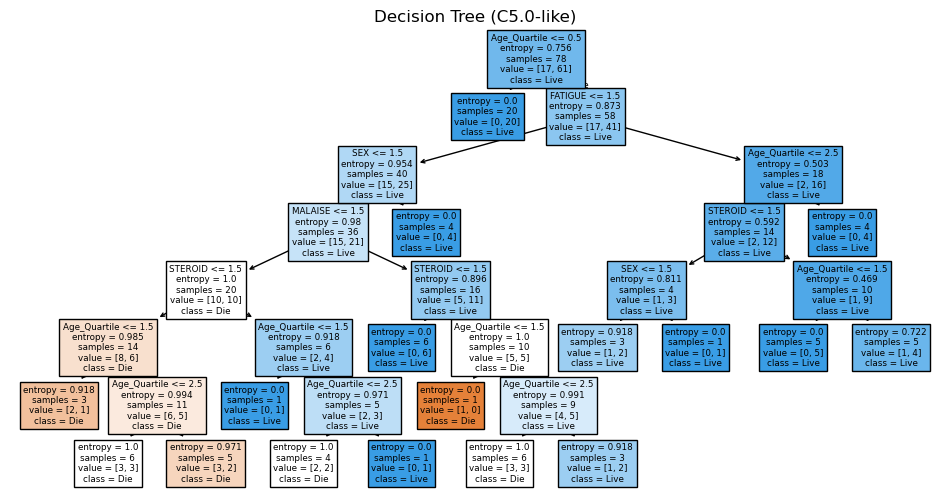

Classification Report:
              precision    recall  f1-score   support

         Die       0.12      0.50      0.20         2
        Live       0.96      0.78      0.86        32

    accuracy                           0.76        34
   macro avg       0.54      0.64      0.53        34
weighted avg       0.91      0.76      0.82        34


Confusion Matrix:
[[ 1  1]
 [ 7 25]]


In [29]:

# Step 2: Select relevant features and target
features = ['SEX', 'Age_Quartile', 'STEROID', 'FATIGUE', 'MALAISE']
target = 'Class'
df_model = df_clean[features + [target]].copy()

# Step 3: Encode categorical variables
le_age = LabelEncoder()
df_model['Age_Quartile'] = le_age.fit_transform(df_model['Age_Quartile'])

# Step 4: Split data into train and test sets (70% train, 30% test)
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Train the decision tree model (C5.0-like using entropy)
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

# Step 6: Make predictions and calculate accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

#Visualize the decision tree
plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=features, class_names=['Die', 'Live'], filled=True)
plt.title("Decision Tree (C5.0-like)")
plt.show()

# Generate classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Die', 'Live']))

# Generate confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


In [30]:
# Summary and conclusion
print("\nConclusion:")
print("The model achieved an accuracy of {:.2f}%.".format(accuracy * 100))


Conclusion:
The model achieved an accuracy of 76.47%.


Although the model achieves a seemingly good accuracy of 76.47%, the performance is highly imbalanced, favoring the majority class (Live). The model struggles to identify mortality cases (Die), which are critical in healthcare prediction. Therefore, this is not a good model for mortality prediction and should be improved using:

Class balancing techniques (e.g., SMOTE, class weights)

Ensemble models (Random Forest, XGBoost)

Collecting more data for minority class (Die)